In [1]:
pip install pandas numpy matplotlib seaborn openpyxl

Dataset loaded successfully!

========== FIRST 5 ROWS ==========
         Date Region     Product  Quantity    Sales  Discount       Profit
0  2025-01-01   East      Laptop         2  17530.0      0.10  2300.993852
1  2025-01-02   West      Laptop         2  15071.0      0.12  1210.175864
2  2025-01-03  North      Laptop        10  10451.0      0.10   783.101679
3  2025-01-04   East  Headphones         7  11273.0      0.13  2163.202813
4  2025-01-05   East       Mouse        12  16640.0      0.15  2393.236346

========== LAST 5 ROWS ==========
            Date Region     Product  Quantity    Sales  Discount       Profit
1000  2025-01-01   East      Laptop         2  17530.0      0.10  2300.993852
1001  2025-01-02   West      Laptop         2  15071.0      0.12  1210.175864
1002  2025-01-03  North      Laptop        10  10451.0      0.10   783.101679
1003  2025-01-04   East  Headphones         7  11273.0      0.13  2163.202813
1004  2025-01-05   East       Mouse        12  16640.0      

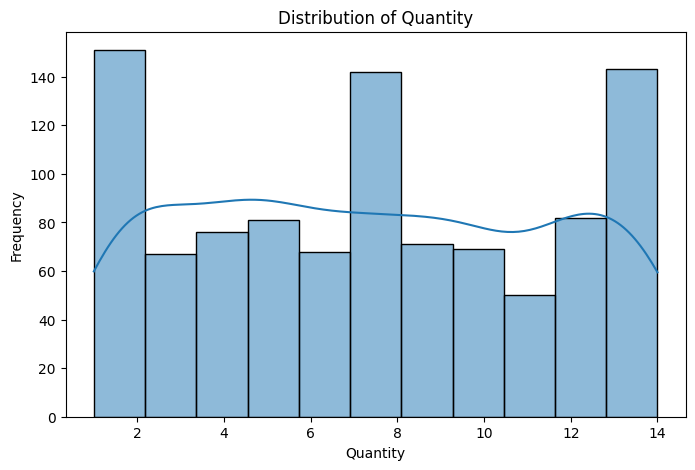

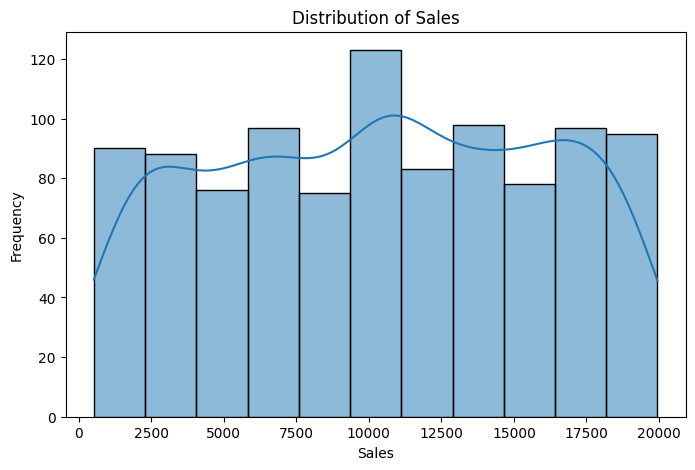

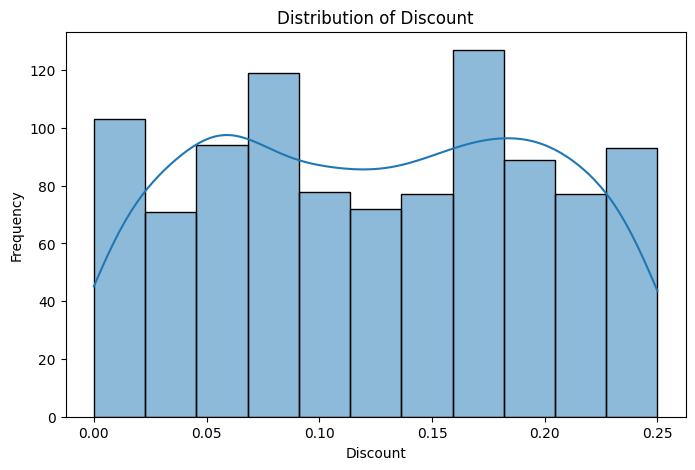

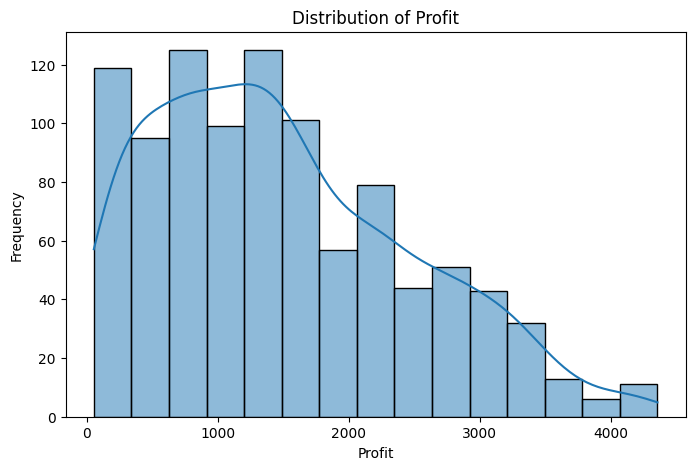


Generating boxplots...


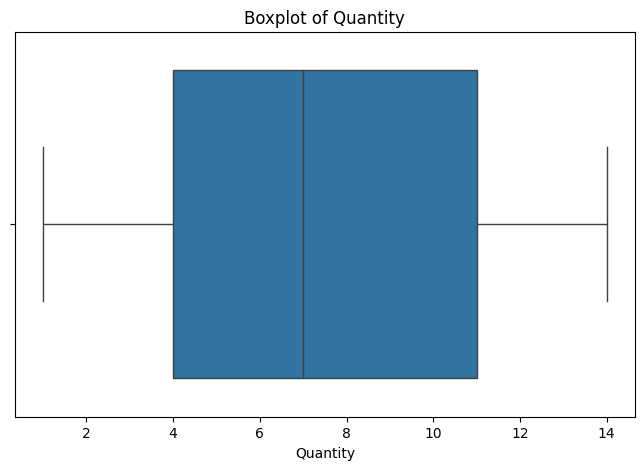

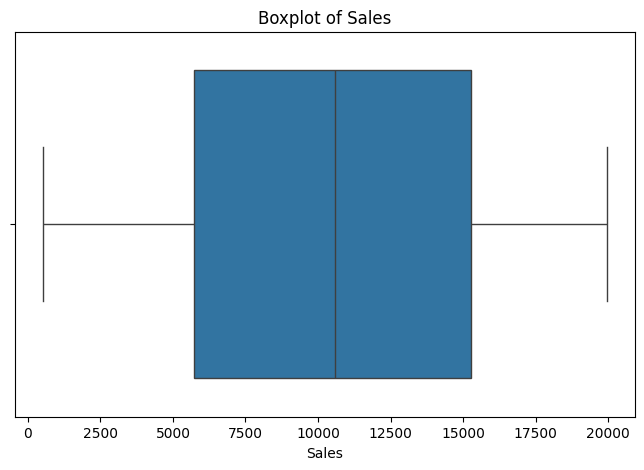

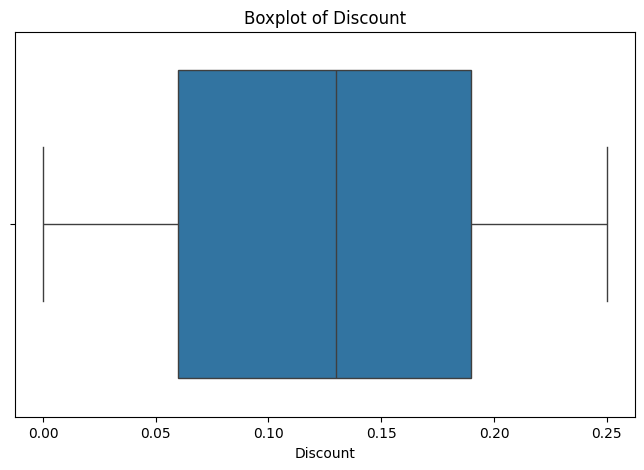

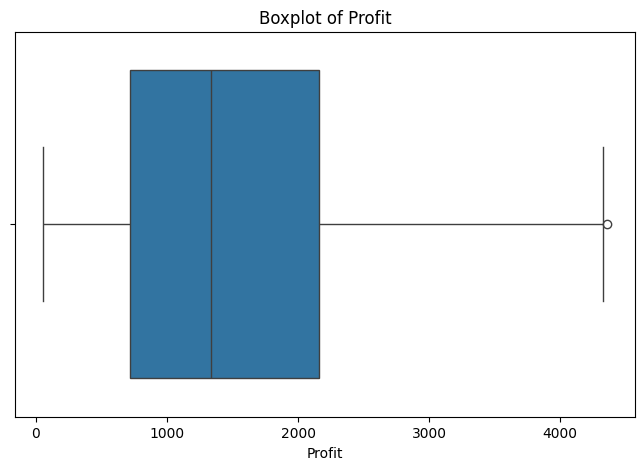


========== OUTLIER DETECTION ==========

Column: Quantity
Q1: 4.0
Q3: 11.0
IQR: 7.0
Lower limit: -6.5
Upper limit: 21.5
Number of outliers: 0

Column: Sales
Q1: 5713.5
Q3: 15263.0
IQR: 9549.5
Lower limit: -8610.75
Upper limit: 29587.25
Number of outliers: 0

Column: Discount
Q1: 0.06
Q3: 0.19
IQR: 0.13
Lower limit: -0.135
Upper limit: 0.385
Number of outliers: 0

Column: Profit
Q1: 720.4131706740754
Q3: 2163.3248580698883
IQR: 1442.9116873958128
Lower limit: -1443.9543604196438
Upper limit: 4327.692389163607
Number of outliers: 1

========== CORRELATION MATRIX ==========
          Quantity     Sales  Discount    Profit
Quantity  1.000000  0.004058 -0.035899  0.003452
Sales     0.004058  1.000000 -0.008570  0.826034
Discount -0.035899 -0.008570  1.000000 -0.157457
Profit    0.003452  0.826034 -0.157457  1.000000


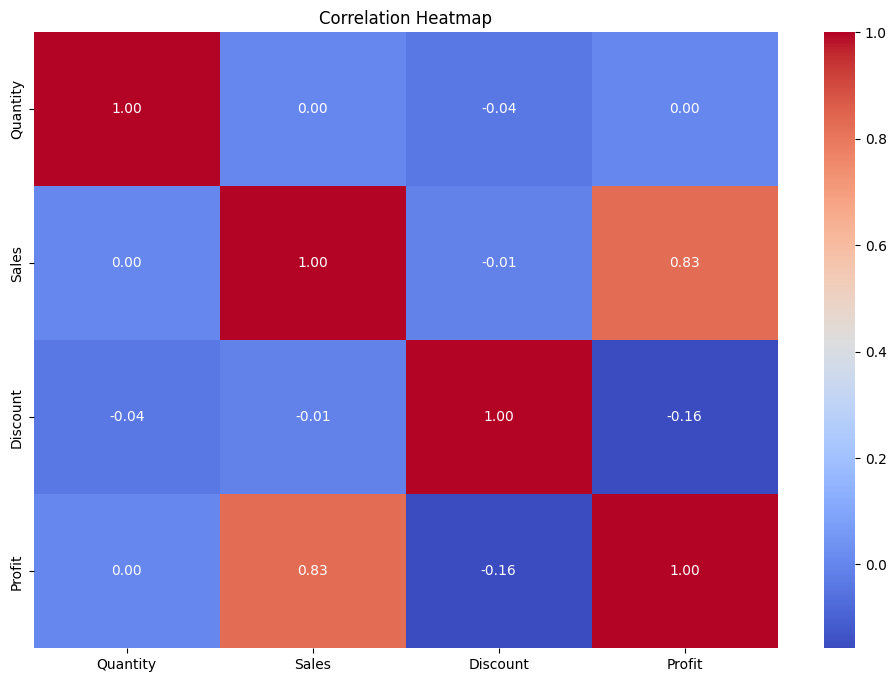

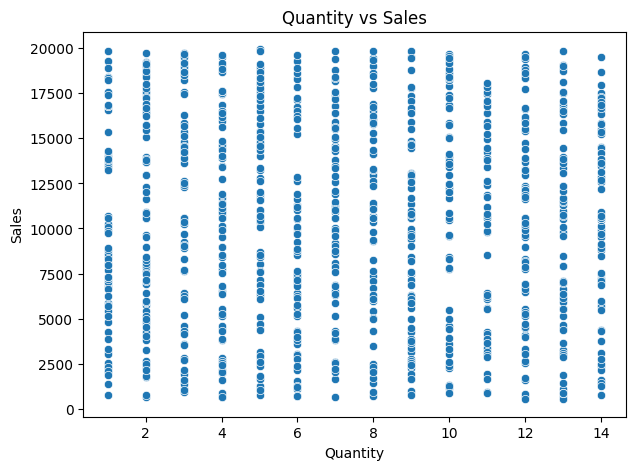

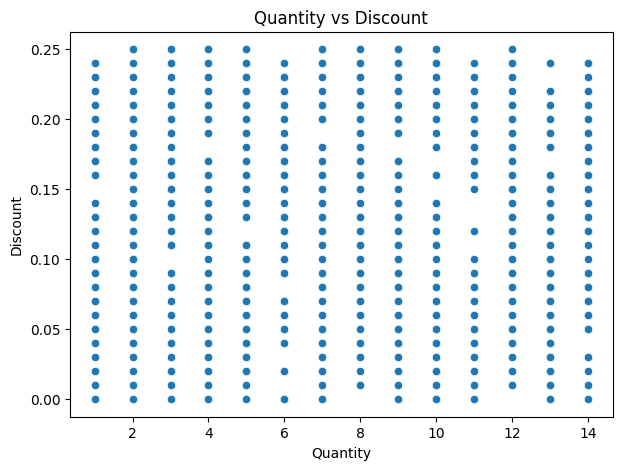

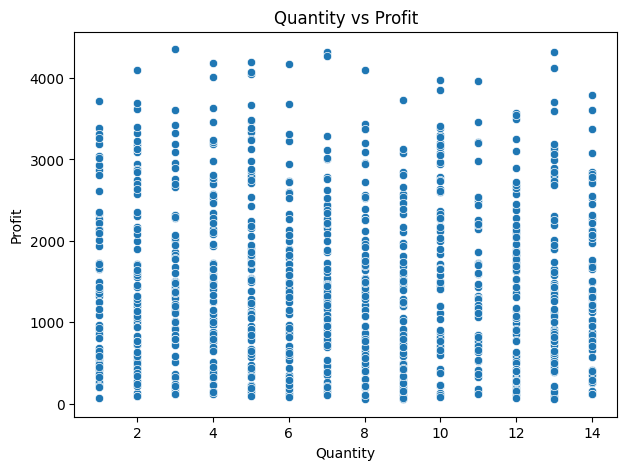

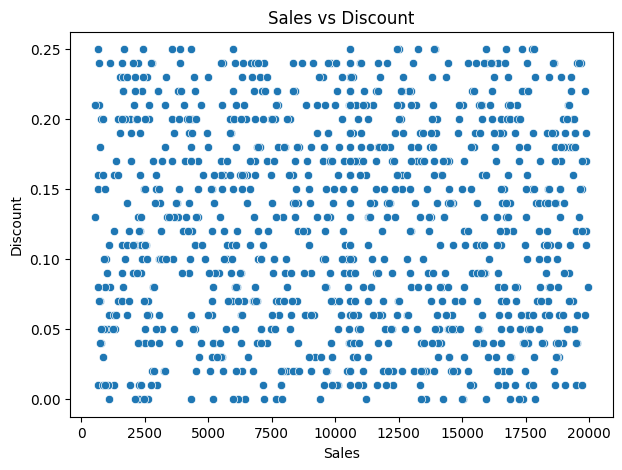

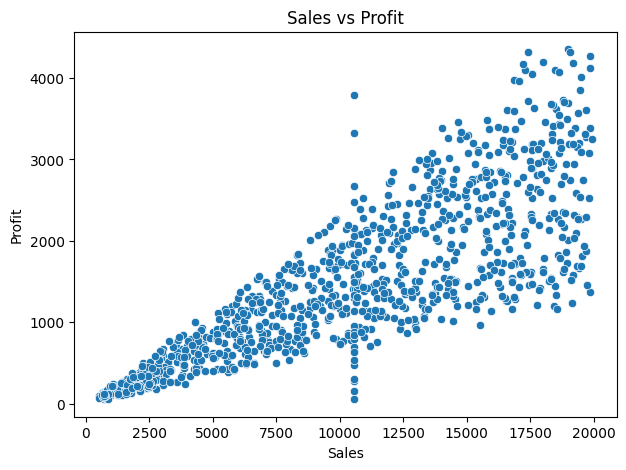

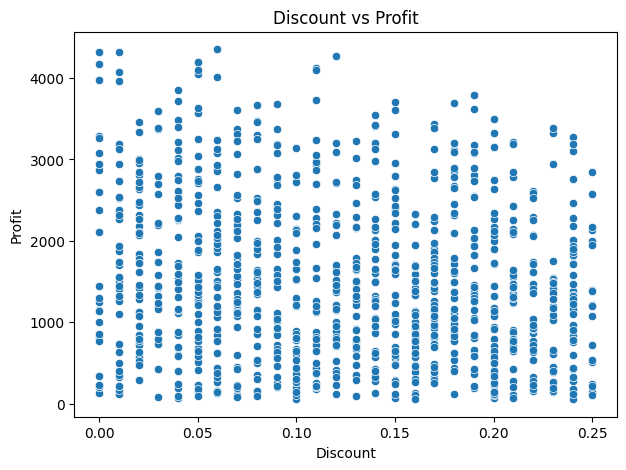

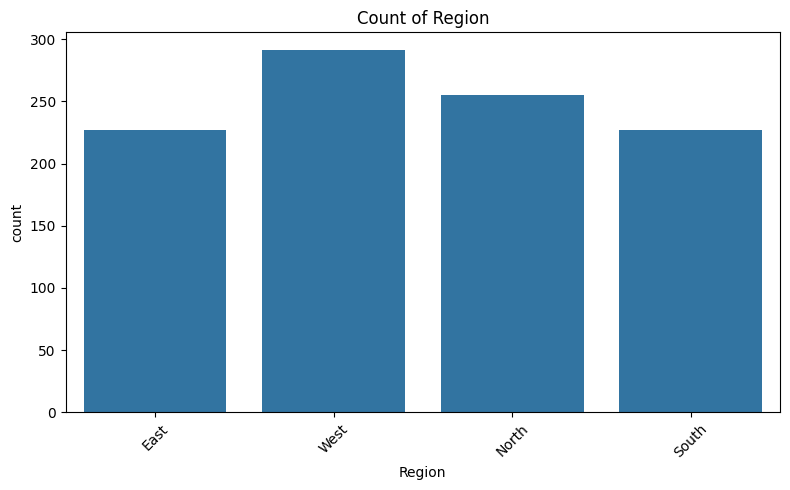

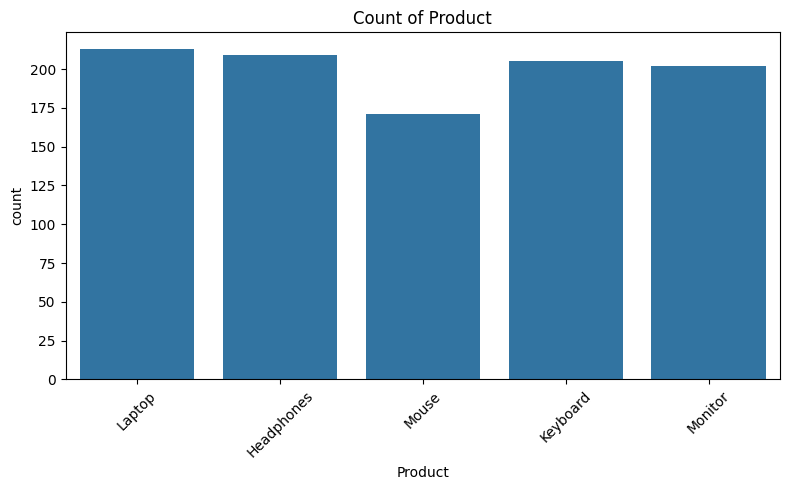

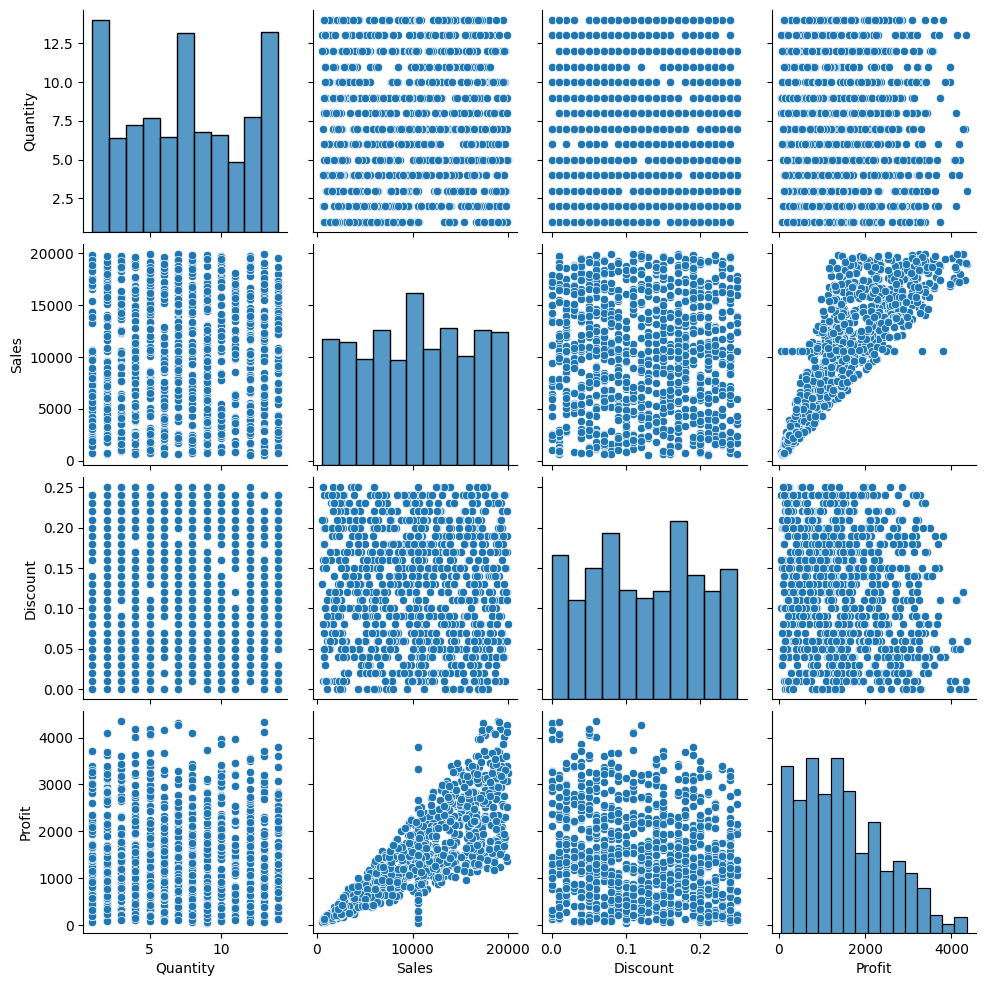


========== SKEWNESS ==========
Quantity -> 0.056897681583115374
Sales -> -0.04850259672938572
Discount -> -0.0036352601642206323
Profit -> 0.6131180096814474

========== FINAL DATASET ==========
Rows: 1000
Columns: 7

Remaining missing values:
Date        0
Region      0
Product     0
Quantity    0
Sales       0
Discount    0
Profit      0
dtype: int64

Remaining duplicates:
0

Cleaned dataset saved as cleaned_dataset.csv

          EDA COMPLETED
Original/Current rows: 1000
Number of columns: 7
Numerical columns: 4
Categorical columns: 3
Duplicate rows: 0
Total missing values: 0

EDA completed successfully!


In [2]:
# ============================================
# COMPLETE EDA PROJECT - 1000 ROW DATASET
# ============================================

# -----------------------------
# 1. IMPORT LIBRARIES
# -----------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display all columns
pd.set_option("display.max_columns", None)

# -----------------------------
# 2. LOAD DATASET
# -----------------------------

df = pd.read_csv("/content/sample_sales.csv")

print("Dataset loaded successfully!")

# -----------------------------
# 3. BASIC INFORMATION
# -----------------------------

print("\n========== FIRST 5 ROWS ==========")
print(df.head())

print("\n========== LAST 5 ROWS ==========")
print(df.tail())

print("\n========== DATASET SHAPE ==========")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\n========== COLUMN NAMES ==========")
print(df.columns.tolist())

print("\n========== DATA TYPES ==========")
print(df.dtypes)

print("\n========== DATASET INFO ==========")
df.info()

# -----------------------------
# 4. DUPLICATE CHECK
# -----------------------------

print("\n========== DUPLICATES ==========")

duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

if duplicate_count > 0:
    df = df.drop_duplicates()
    print("Duplicates removed.")
else:
    print("No duplicate rows found.")

# -----------------------------
# 5. MISSING VALUES
# -----------------------------

print("\n========== MISSING VALUES ==========")

missing_values = df.isnull().sum()

print(missing_values)

print("\nMissing percentage:")

missing_percentage = (df.isnull().sum() / len(df)) * 100

print(missing_percentage)

# -----------------------------
# 6. HANDLE MISSING VALUES
# -----------------------------

# Separate numerical and categorical columns

numerical_columns = df.select_dtypes(
    include=np.number
).columns

categorical_columns = df.select_dtypes(
    include="object"
).columns

print("\nNumerical columns:")
print(numerical_columns.tolist())

print("\nCategorical columns:")
print(categorical_columns.tolist())

# Fill numerical missing values with median

for column in numerical_columns:
    df[column] = df[column].fillna(df[column].median())

# Fill categorical missing values with mode

for column in categorical_columns:
    if df[column].isnull().sum() > 0:
        df[column] = df[column].fillna(df[column].mode()[0])

print("\nMissing values after cleaning:")
print(df.isnull().sum())

# -----------------------------
# 7. CHECK UNIQUE VALUES
# -----------------------------

print("\n========== UNIQUE VALUES ==========")

for column in df.columns:
    print(
        column,
        "->",
        df[column].nunique(),
        "unique values"
    )

# -----------------------------
# 8. DESCRIPTIVE STATISTICS
# -----------------------------

print("\n========== DESCRIPTIVE STATISTICS ==========")

print(df.describe())

# Include categorical columns

print("\n========== ALL STATISTICS ==========")

print(df.describe(include="all"))

# -----------------------------
# 9. VALUE COUNTS
# -----------------------------

print("\n========== CATEGORICAL DATA ==========")

for column in categorical_columns:

    print("\nColumn:", column)

    print(df[column].value_counts().head(10))

# -----------------------------
# 10. NUMERICAL DISTRIBUTION
# -----------------------------

print("\n========== NUMERICAL DISTRIBUTION ==========")

for column in numerical_columns:

    print("\nColumn:", column)

    print("Mean:", df[column].mean())
    print("Median:", df[column].median())
    print("Minimum:", df[column].min())
    print("Maximum:", df[column].max())
    print("Standard Deviation:", df[column].std())

# -----------------------------
# 11. HISTOGRAMS
# -----------------------------

print("\nGenerating histograms...")

for column in numerical_columns:

    plt.figure(figsize=(8, 5))

    sns.histplot(
        df[column],
        kde=True
    )

    plt.title("Distribution of " + column)
    plt.xlabel(column)
    plt.ylabel("Frequency")

    plt.show()

# -----------------------------
# 12. BOXPLOTS
# -----------------------------

print("\nGenerating boxplots...")

for column in numerical_columns:

    plt.figure(figsize=(8, 5))

    sns.boxplot(
        x=df[column]
    )

    plt.title("Boxplot of " + column)
    plt.xlabel(column)

    plt.show()

# -----------------------------
# 13. OUTLIER DETECTION
# -----------------------------

print("\n========== OUTLIER DETECTION ==========")

for column in numerical_columns:

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower_limit) |
        (df[column] > upper_limit)
    ]

    print("\nColumn:", column)
    print("Q1:", Q1)
    print("Q3:", Q3)
    print("IQR:", IQR)
    print("Lower limit:", lower_limit)
    print("Upper limit:", upper_limit)
    print("Number of outliers:", len(outliers))

# -----------------------------
# 14. CORRELATION MATRIX
# -----------------------------

print("\n========== CORRELATION MATRIX ==========")

correlation = df[numerical_columns].corr()

print(correlation)

# -----------------------------
# 15. CORRELATION HEATMAP
# -----------------------------

plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

# -----------------------------
# 16. SCATTER PLOTS
# -----------------------------

# Create scatter plots for numerical columns

if len(numerical_columns) >= 2:

    for i in range(len(numerical_columns)):

        for j in range(i + 1, len(numerical_columns)):

            plt.figure(figsize=(7, 5))

            sns.scatterplot(
                data=df,
                x=numerical_columns[i],
                y=numerical_columns[j]
            )

            plt.title(
                numerical_columns[i]
                + " vs "
                + numerical_columns[j]
            )

            plt.show()

# -----------------------------
# 17. CATEGORICAL BAR CHARTS
# -----------------------------

for column in categorical_columns:

    # Only show columns with reasonable number
    # of categories

    if df[column].nunique() <= 20:

        plt.figure(figsize=(8, 5))

        sns.countplot(
            data=df,
            x=column
        )

        plt.title("Count of " + column)

        plt.xticks(rotation=45)

        plt.tight_layout()

        plt.show()

# -----------------------------
# 18. PAIRPLOT
# -----------------------------

if len(numerical_columns) <= 6:

    sns.pairplot(
        df[numerical_columns]
    )

    plt.show()

# -----------------------------
# 19. SKEWNESS
# -----------------------------

print("\n========== SKEWNESS ==========")

for column in numerical_columns:

    print(
        column,
        "->",
        df[column].skew()
    )

# -----------------------------
# 20. DATASET AFTER CLEANING
# -----------------------------

print("\n========== FINAL DATASET ==========")

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nRemaining missing values:")
print(df.isnull().sum())

print("\nRemaining duplicates:")
print(df.duplicated().sum())

# -----------------------------
# 21. SAVE CLEANED DATASET
# -----------------------------

df.to_csv(
    "cleaned_dataset.csv",
    index=False
)

print("\nCleaned dataset saved as cleaned_dataset.csv")

# -----------------------------
# 22. FINAL SUMMARY
# -----------------------------

print("\n===================================")
print("          EDA COMPLETED")
print("===================================")

print("Original/Current rows:", df.shape[0])
print("Number of columns:", df.shape[1])
print("Numerical columns:", len(numerical_columns))
print("Categorical columns:", len(categorical_columns))
print("Duplicate rows:", df.duplicated().sum())
print(
    "Total missing values:",
    df.isnull().sum().sum()
)

print("\nEDA completed successfully!")